<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Golden_Section_Search_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [4]:
# !uv pip install numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Control Knobs ---
INITIAL_LOWER_BOUND = 0.5
INITIAL_UPPER_BOUND = 5.0
CONVERGENCE_TOLERANCE = 1e-4
MAXIMUM_ITERATIONS = 15
ANIMATION_INTERVAL_MS = 1200
GOLDEN_RATIO = (1.0 + np.sqrt(5.0)) / 2.0
# ---------------------

# Establish high-resolution rendering for the Colab notebook output
plt.rcParams['figure.dpi'] = 200

def objective_function(radius: float) -> float:
    """
    Calculate the combined cost of a rotating shaft.

    The function penalizes excessive material mass while simultaneously
    penalizing extreme deflection characteristics of a small radius.
    """
    material_cost = 2.0 * np.pi * radius**2
    deflection_penalty = 50.0 / (radius**3)
    return material_cost + deflection_penalty

def perform_golden_section_search(func, xl, xu, tol, max_iter):
    """
    Execute the golden section search to find the minimum of a function.

    Returns a history of the intervals for visualization purposes.
    """
    history = []

    # Calculate initial interior points
    d = (xu - xl) / GOLDEN_RATIO
    x1 = xu - d
    x2 = xl + d

    f1 = func(x1)
    f2 = func(x2)

    history.append((xl, xu, x1, x2))

    for _ in range(max_iter):
        if abs(xu - xl) < tol:
            break

        if f1 < f2:
            xu = x2
            x2 = x1
            f2 = f1
            d = (xu - xl) / GOLDEN_RATIO
            x1 = xu - d
            f1 = func(x1)
        else:
            xl = x1
            x1 = x2
            f1 = f2
            d = (xu - xl) / GOLDEN_RATIO
            x2 = xl + d
            f2 = func(x2)

        history.append((xl, xu, x1, x2))

    return history

# Execute the algorithm and retrieve the geometric history
iteration_history = perform_golden_section_search(
    objective_function,
    INITIAL_LOWER_BOUND,
    INITIAL_UPPER_BOUND,
    CONVERGENCE_TOLERANCE,
    MAXIMUM_ITERATIONS
)

# Prepare the visualization canvas
fig, ax = plt.subplots(figsize=(8, 5))
x_vals = np.linspace(INITIAL_LOWER_BOUND, INITIAL_UPPER_BOUND, 400)
y_vals = objective_function(x_vals)

# Plot the static objective function curve
ax.plot(x_vals, y_vals, label='Cost Function', color='navy')
ax.set_xlabel('Shaft Radius (arbitrary units)')
ax.set_ylabel('Total Penalized Cost')
ax.set_title('Golden Section Search Optimization')

# Initialize dynamic visual elements
lower_bound_line = ax.axvline(x=0, color='red', linestyle='--', label='Bounds (xl, xu)')
upper_bound_line = ax.axvline(x=0, color='red', linestyle='--')
x1_scatter = ax.scatter([], [], color='green', zorder=5, label='Interior Points')
x2_scatter = ax.scatter([], [], color='green', zorder=5)

# Utilize Rectangle patches to span the y-axis dynamically based on the x-axis transform
left_discard_region = patches.Rectangle(
    (INITIAL_LOWER_BOUND, 0), 0, 1,
    alpha=0.2, color='gray', transform=ax.get_xaxis_transform()
)
right_discard_region = patches.Rectangle(
    (INITIAL_UPPER_BOUND, 0), 0, 1,
    alpha=0.2, color='gray', transform=ax.get_xaxis_transform()
)
ax.add_patch(left_discard_region)
ax.add_patch(right_discard_region)

ax.legend(loc='upper right')

def update_animation(frame_index):
    """Update the plot elements for the current iteration frame."""
    xl, xu, x1, x2 = iteration_history[frame_index]

    lower_bound_line.set_xdata([xl, xl])
    upper_bound_line.set_xdata([xu, xu])

    x1_scatter.set_offsets(np.c_[x1, objective_function(x1)])
    x2_scatter.set_offsets(np.c_[x2, objective_function(x2)])

    # Update the left discarded region coordinates and width
    left_discard_region.set_xy((INITIAL_LOWER_BOUND, 0))
    left_discard_region.set_width(xl - INITIAL_LOWER_BOUND)

    # Update the right discarded region coordinates and width
    right_discard_region.set_xy((xu, 0))
    right_discard_region.set_width(INITIAL_UPPER_BOUND - xu)

    ax.set_title(f'GSS Iteration {frame_index + 1} | Interval Width: {xu - xl:.4f}')
    return (lower_bound_line, upper_bound_line, x1_scatter, x2_scatter,
            left_discard_region, right_discard_region)

# Generate the animation sequence
anim = FuncAnimation(
    fig,
    update_animation,
    frames=len(iteration_history),
    interval=ANIMATION_INTERVAL_MS,
    blit=False
)

# Render the animation explicitly within the notebook environment
plt.close() # Prevent static plot rendering alongside the animation
HTML(anim.to_jshtml())

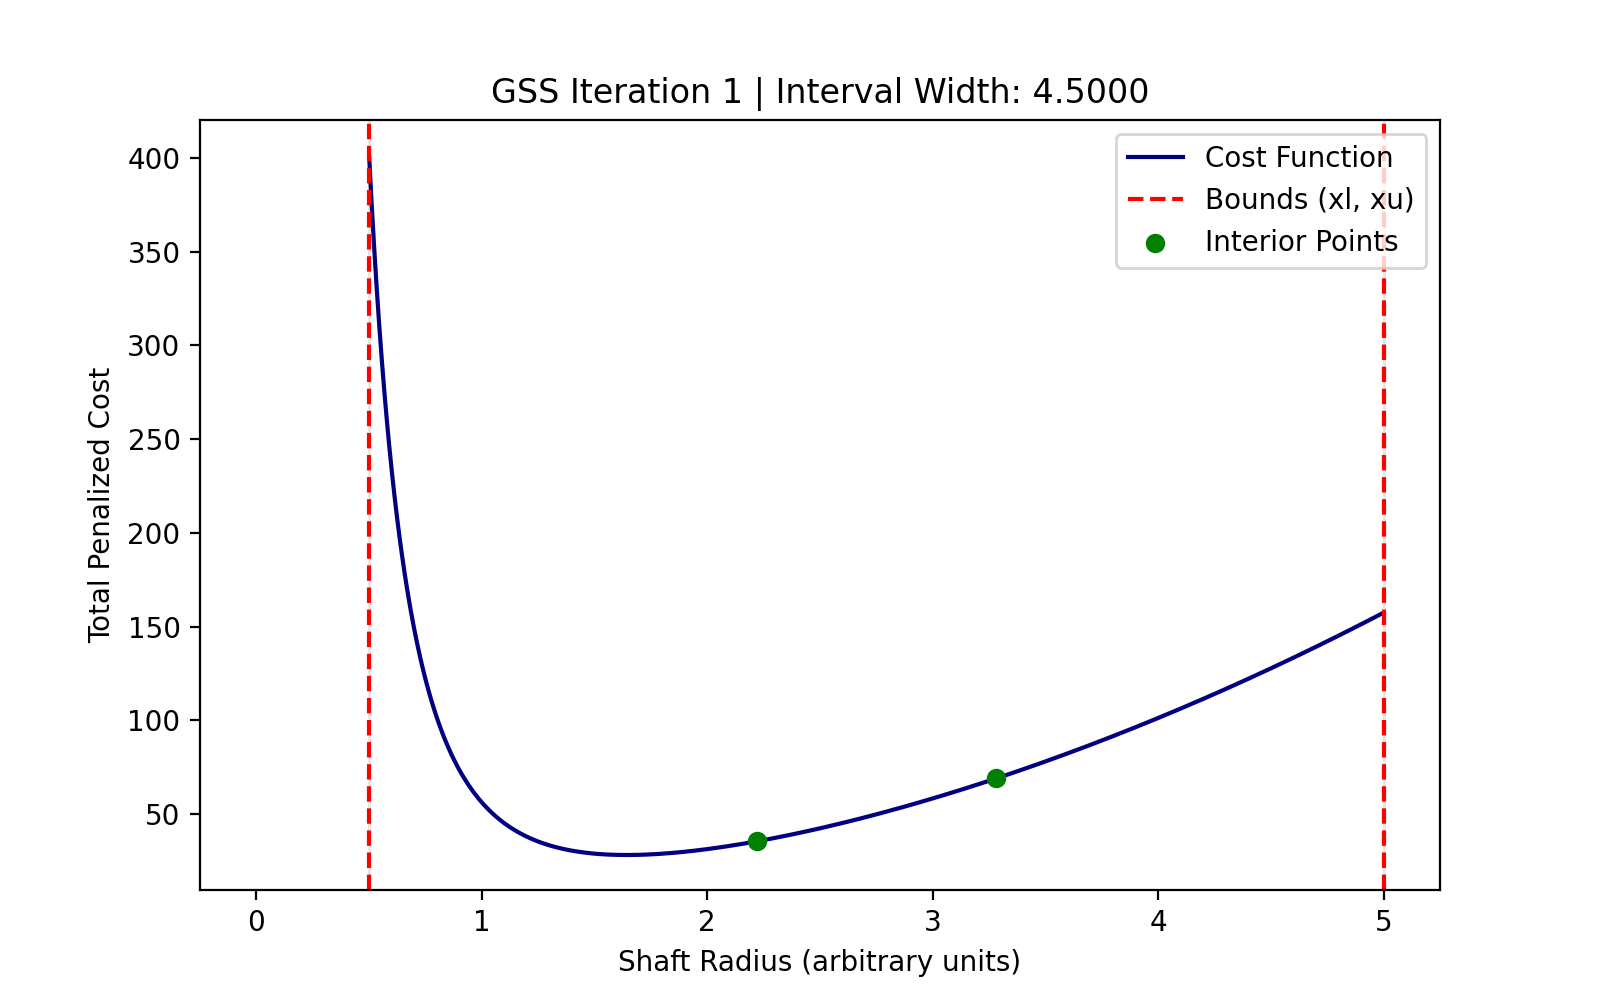

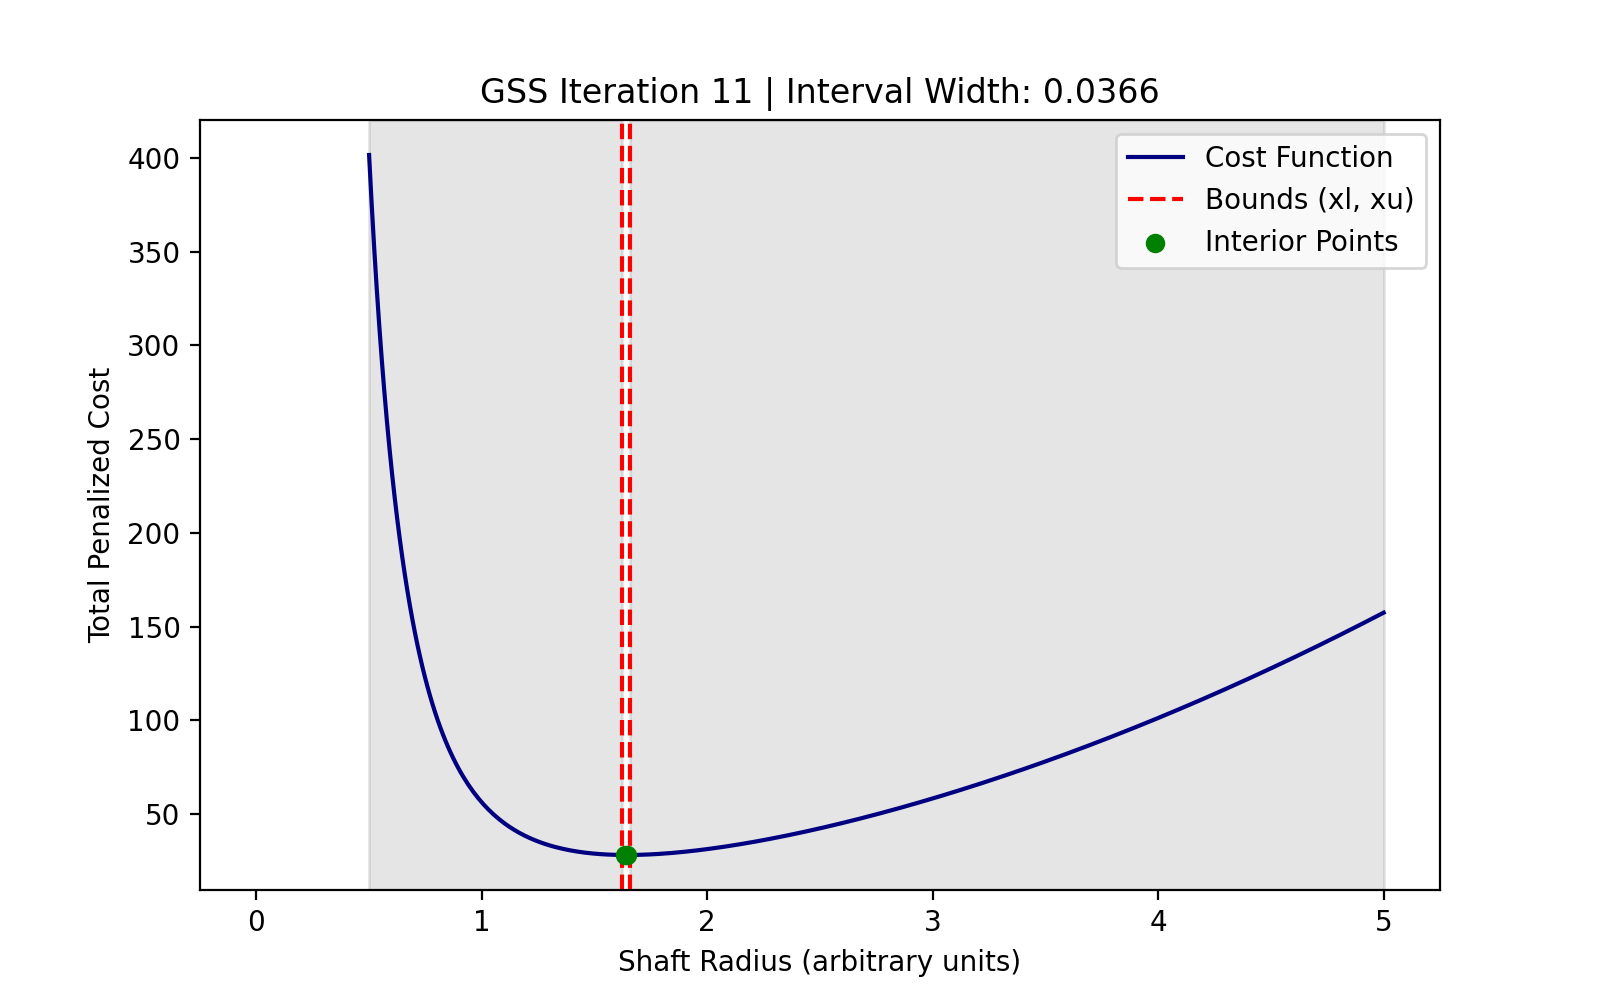